In [10]:
import pandas as pd
import numpy as np
from typing import List, Tuple
from datetime import datetime
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pymongo import MongoClient, UpdateOne
from pymongo.server_api import ServerApi
import requests
import json
import time
from os import read
from datetime import date



In [26]:
from dotenv import load_dotenv
import os
load_dotenv() 

class TMDBMoviePipeline:
    """A rerunnable ETL pipeline to fetch, clean, analyze, and visualize data

    from the TMDB discover/movie API.
    """

    BASE_URL = "https://api.themoviedb.org/3/discover/movie"


    def __init__(self, API_KEY: str):
        """Initializes the pipeline with a TMDB API Key."""
        self.api_key = API_KEY
        self.raw_df = pd.DataFrame()
        self.cleaned_df = pd.DataFrame()

    def fetch_data(self, max_pages: int = 3) -> pd.DataFrame:
        """Pulls data from the TMDB API and handles pagination seamlessly."""
        print(f"--- STARTING INGESTION (Target: {max_pages} pages) ---")
        all_movies = []

        for page in range(1, max_pages + 1):
            headers = {
                "accept": "application/json",
                "Authorization": os.getenv("API_KEY")
            }

            params = {
                "include_adult": "false",
                "include_video": "false",
                "language": "en-US",
                "page": page,
                "sort_by": "popularity.desc"
            }
            
            try:
                response = requests.get(self.BASE_URL, headers=headers, params=params, timeout=10)
                if response.status_code == 401:
                    raise ValueError(
                        "Invalid API Key. Please verify your TMDB credentials."
                    )
                response.raise_for_status()

                data = response.json()
                results = data.get("results", [])

                if not results:
                    print(f"No more results found at page {page}. Stopping.")
                    break

                all_movies.extend(results)
                print(f"Successfully fetched page {page}/{max_pages}")

                # Polite API scraping pause
                time.sleep(0.2)

            except requests.exceptions.RequestException as e:
                print(f"❌ Error fetching page {page}: {e}")
                break

        self.raw_df = pd.DataFrame(all_movies)
        print(f"Ingestion complete. Gathered {len(self.raw_df)} raw records.\n")
        return self.raw_df

    def clean_data(self) -> pd.DataFrame:
        """Cleans TMDB data: removes duplicates, handles missing values,

        and standardizes date types.
        """
        if self.raw_df.empty:
            raise ValueError(
                "No data found to clean. Please run `fetch_data()` first."
            )

        print("--- STARTING DATA CLEANING ---")
        df = self.raw_df.copy()

        # 1. Deduplication using TMDB unique ID
        initial_count = len(df)
        df.drop_duplicates(subset=["id"], keep="first", inplace=True)
        print(f"✔️ Removed {initial_count - len(df)} duplicate movie records.")

        # 2. Correct Date Datatype (TMDB format: YYYY-MM-DD)
        if "release_date" in df.columns:
            df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
            print("✔️ Standardized 'release_date' column to datetime.")

        # 3. Handle Missing Numeric Columns (Popularity, Vote Average, Vote Count)
        numeric_cols = ["popularity", "vote_average", "vote_count"]
        for col in numeric_cols:
            if col in df.columns and df[col].isnull().any():
                median_val = df[col].median()
                df[col].fillna(median_val, inplace=True)
                print(f"✔️ Filled missing values in '{col}' with median ({median_val}).")

        # 4. Handle Missing Text Columns
        text_cols = ["title", "overview", "original_language"]
        for col in text_cols:
            if col in df.columns:
                df[col] = df[col].fillna("Unknown")


        self.cleaned_df = df
        print(f"Final Cleaned Dataset Shape: {self.cleaned_df.shape}\n")
        return self.cleaned_df

    def analyze_data(self) -> dict:
        """Performs analytical summaries on the processed TMDB dataset."""
        if self.cleaned_df.empty:
            raise ValueError("No cleaned data found. Please run `clean_data()` first.")

        print("--- STARTING DATA ANALYSIS ---")
        df = self.cleaned_df

        analysis = {
            "total_movies": len(df),
            "average_rating": df["vote_average"].mean() if "vote_average" in df.columns else 0,
            "top_genres_tracked": df["genre_ids"].apply(len).mean() if "genre_ids" in df.columns else 0,
            "languages": df["original_language"].value_counts().to_dict() if "original_language" in df.columns else {},
        }

        print(f"Total Movies Processed: {analysis['total_movies']}")
        print(f"Mean Audience Rating: {analysis['average_rating']:.2f}/10")
        print("\nStatistical Distribution Summary:")
        print(df[["popularity", "vote_average", "vote_count", "original_language", "genre_ids"]].describe())
        print("\n")

        return analysis

    def handle_visualizations(self):
        """Generates a professional data visualization dashboard using the processed data."""
        if self.cleaned_df.empty:
            raise ValueError("No data available to plot. Please run `clean_data()` first.")

        print("--- GENERATING VISUALIZATIONS ---")
        sns.set_theme(style="darkgrid")
        df = self.cleaned_df

        # Initialize dashboard layout
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        fig.suptitle("TMDB Movie Discovery Insights Dashboard", fontsize=16, fontweight="bold")

        # Chart 1: Distribution of Vote Averages
        if "vote_average" in df.columns:
            sns.histplot(data=df, x="vote_average", kde=True, bins=15, color="teal", ax=axes[0])
            axes[0].set_title("Distribution of User Ratings", fontsize=12)
            axes[0].set_xlabel("Vote Average (0-10)")
            axes[0].set_ylabel("Count")

        # Chart 2: Popularity vs User Rating Correlation
        if "popularity" in df.columns and "vote_average" in df.columns:
            sns.scatterplot(data=df, x="vote_average", y="popularity", alpha=0.7, color="crimson", ax=axes[1])
            axes[1].set_title("Popularity vs. User Rating", fontsize=12)
            axes[1].set_xlabel("Vote Average")
            axes[1].set_ylabel("Popularity Metric")

        # Chart 3: Top Original Languages Represented
        if "original_language" in df.columns:
            lang_counts = df["original_language"].value_counts().head(5)
            sns.barplot(x=lang_counts.index, y=lang_counts.values, hue=lang_counts.index, palette="viridis", legend=False, ax=axes[2])
            axes[2].set_title("Top 5 Original Languages", fontsize=12)
            axes[2].set_xlabel("Language Code")
            axes[2].set_ylabel("Number of Movies")

        plt.tight_layout()
        plt.show()


--- STARTING INGESTION (Target: 5 pages) ---
Successfully fetched page 1/5
Successfully fetched page 2/5
Successfully fetched page 3/5
Successfully fetched page 4/5
Successfully fetched page 5/5
Ingestion complete. Gathered 100 raw records.

--- STARTING DATA CLEANING ---
✔️ Removed 10 duplicate movie records.
✔️ Standardized 'release_date' column to datetime.
Final Cleaned Dataset Shape: (90, 15)

--- STARTING DATA ANALYSIS ---
Total Movies Processed: 90
Mean Audience Rating: 6.89/10

Statistical Distribution Summary:
       popularity  vote_average    vote_count
count   90.000000     90.000000     90.000000
mean   111.606727      6.890111   6248.155556
std    108.265256      1.832525  11426.176969
min     41.479000      0.000000      0.000000
25%     54.179375      6.348250     54.500000
50%     72.990000      7.400000    741.000000
75%    113.206200      8.062250   3612.250000
max    691.719800      9.176000  41155.000000


--- GENERATING VISUALIZATIONS ---


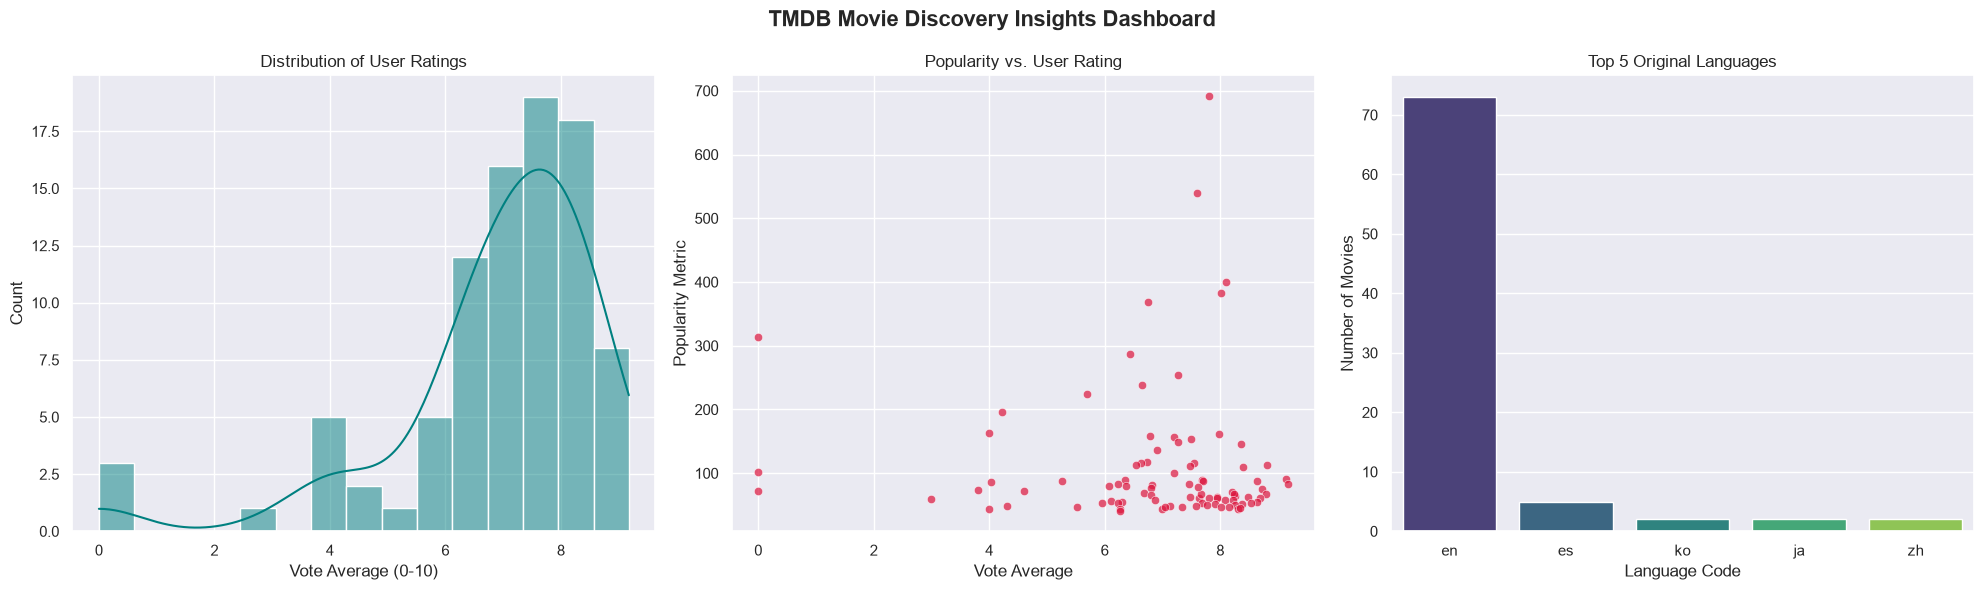

In [27]:
from dotenv import load_dotenv
import os
load_dotenv() 

# 1. Supply your TMDB v3 API Key
YOUR_TMDB_API_KEY = os.getenv("API_KEY")
# 2. Instantiate the modular pipeline
tmdb_pipeline = TMDBMoviePipeline(API_KEY=YOUR_TMDB_API_KEY)

# 3. Pull data across multiple pages (e.g., fetch the top 5 pages of movies)
raw_movies = tmdb_pipeline.fetch_data(max_pages=5)

# 4. Clean, transform datatypes, and structure the data
cleaned_movies = tmdb_pipeline.clean_data()

# 5. Extract structural analytics
summary_metrics = tmdb_pipeline.analyze_data()

# 6. Build the data analysis dashboard
tmdb_pipeline.handle_visualizations()
